       ANOMALİ TESPİTİ SİSTEMİ BAŞLATILIYOR
[WARNING] CSV bulunamadı: data.csv
[INFO] Örnek veri oluşturuluyor...
[INFO] Örnek veri 'sample_generated_data.csv' olarak kaydedildi.

[INFO] Veri setinin ilk 5 satırı:
    sensor_1    sensor_2   sensor_3  label
0  48.911594   98.505027  74.849838      0
1  45.507927  106.563857  77.759833      0
2  57.896064   95.260849  80.371159      0
3  48.882686   90.222978  69.062231      0
4  50.458804   88.171310  84.004559      0

[INFO] Veri seti boyutu: (525, 4)

[INFO] Sütunlar: ['sensor_1', 'sensor_2', 'sensor_3', 'label']

[INFO] Modele verilen özellikler:
['sensor_1', 'sensor_2', 'sensor_3', 'label']

[INFO] Sonuçlar kaydedildi: anomaly_results.csv

================== ÖZET ==================
Toplam kayıt sayısı    : 525
Normal kayıt sayısı    : 498
Anomali kayıt sayısı   : 27
Anomali oranı (%)      : 5.14

İlk 10 anomali kayıt:
      sensor_1    sensor_2    sensor_3  label  anomaly_prediction  \
6    88.883380   34.907733  132.332150      1  

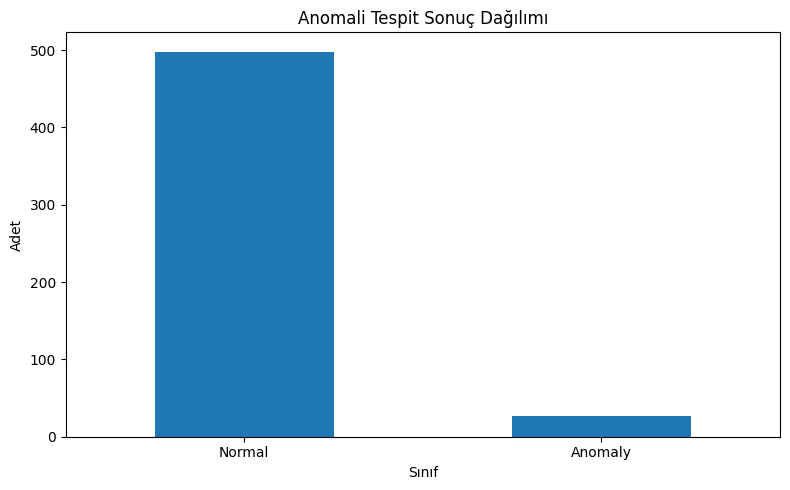

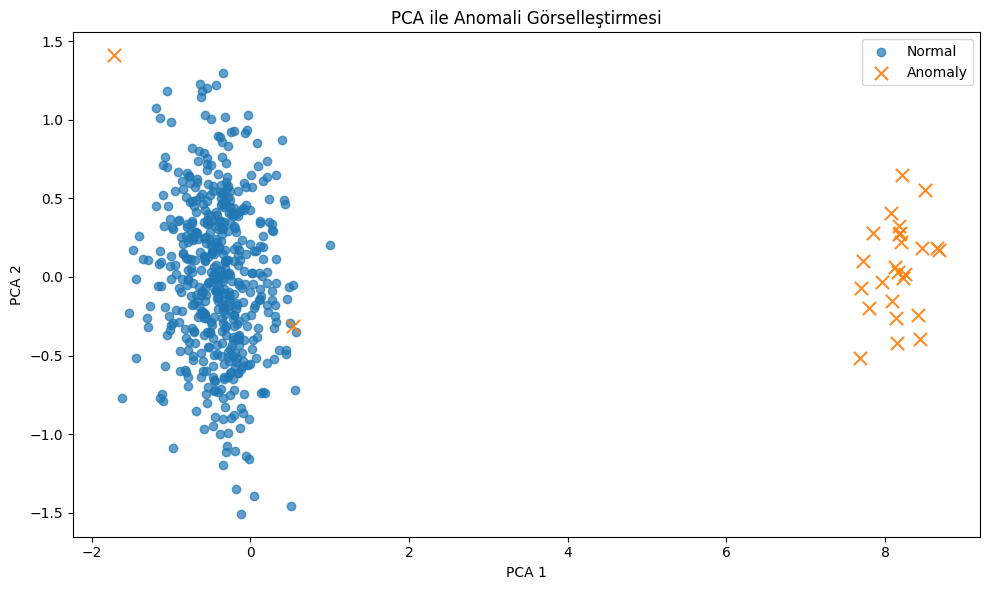

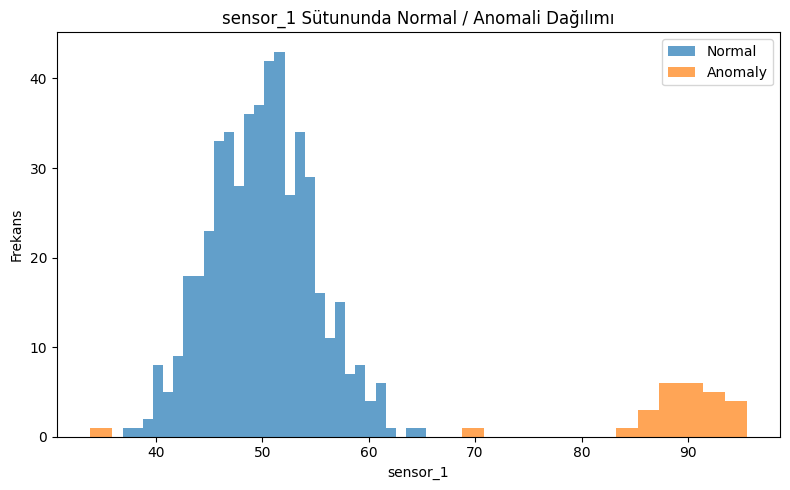

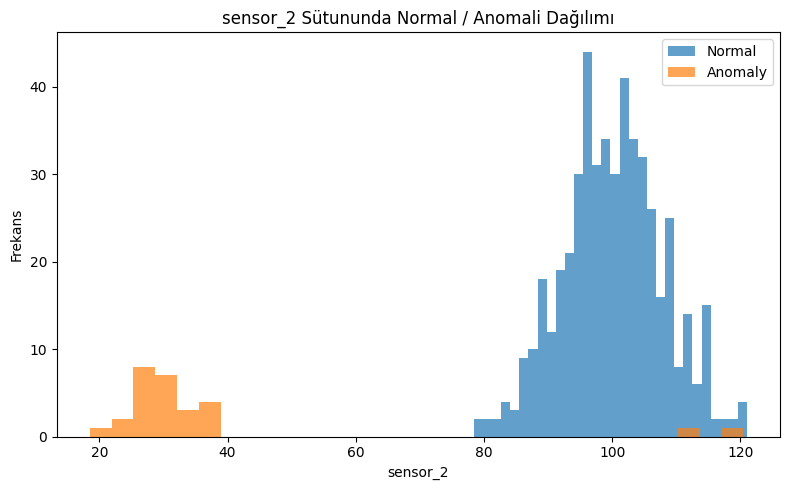

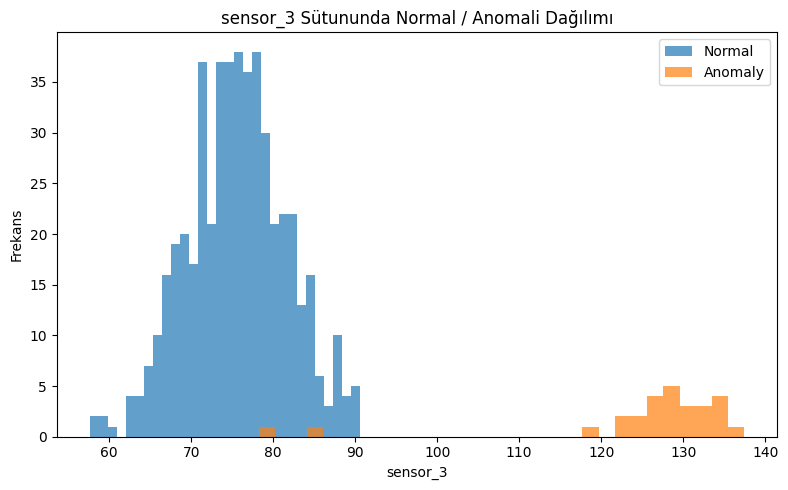


[INFO] Sistem başarıyla tamamlandı.


In [ ]:
# ============================================================
# ANOMALİ TESPİTİ SİSTEMİ
# Tek Parça Kod - Colab ve VS Code Uyumlu
# Hazırlayan: ChatGPT
# ============================================================

import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# 1) AYARLAR
# ============================================================

# CSV dosya yolu:
# VS Code için örnek: "data.csv"
# Colab için örnek: "/content/data.csv"
FILE_PATH = "data.csv"

# Hedef olarak kullanılacak etiket sütunu varsa adı yazılabilir.
# Yoksa None bırak.
# Örn: TARGET_COLUMN = "label"
# Label içinde normal=0, anomaly=1 gibi değerler olabilir
TARGET_COLUMN = None

# Veri setinde zaman sütunu varsa adı yazılabilir, yoksa None bırak
TIME_COLUMN = None

# Anomali oranı tahmini (modelin beklediği anomali yüzdesi)
CONTAMINATION = 0.05

# Rastgelelik kontrolü
RANDOM_STATE = 42

# Çıktı dosyası
OUTPUT_FILE = "anomaly_results.csv"

# Görselleri kaydetmek istersen True yap
SAVE_FIGURES = True


# ============================================================
# 2) ÖRNEK VERİ ÜRETİCİ
# ============================================================

def generate_sample_data(n_normal=500, n_anomaly=25, random_state=42):
    """
    CSV dosyası yoksa örnek veri üretir.
    2 boyutlu normal veri + birkaç anomali.
    """
    np.random.seed(random_state)

    # Normal veri
    normal_1 = np.random.normal(loc=50, scale=5, size=n_normal)
    normal_2 = np.random.normal(loc=100, scale=8, size=n_normal)
    normal_3 = np.random.normal(loc=75, scale=6, size=n_normal)

    normal_df = pd.DataFrame({
        "sensor_1": normal_1,
        "sensor_2": normal_2,
        "sensor_3": normal_3,
        "label": 0
    })

    # Anomali veri
    anomaly_1 = np.random.normal(loc=90, scale=3, size=n_anomaly)
    anomaly_2 = np.random.normal(loc=30, scale=4, size=n_anomaly)
    anomaly_3 = np.random.normal(loc=130, scale=5, size=n_anomaly)

    anomaly_df = pd.DataFrame({
        "sensor_1": anomaly_1,
        "sensor_2": anomaly_2,
        "sensor_3": anomaly_3,
        "label": 1
    })

    df = pd.concat([normal_df, anomaly_df], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df


# ============================================================
# 3) VERİ YÜKLEME
# ============================================================

def load_data(file_path):
    """
    Dosya varsa CSV'den okur, yoksa örnek veri üretir.
    """
    if os.path.exists(file_path):
        print(f"[INFO] CSV bulundu: {file_path}")
        df = pd.read_csv(file_path)
    else:
        print(f"[WARNING] CSV bulunamadı: {file_path}")
        print("[INFO] Örnek veri oluşturuluyor...")
        df = generate_sample_data()
        df.to_csv("sample_generated_data.csv", index=False)
        print("[INFO] Örnek veri 'sample_generated_data.csv' olarak kaydedildi.")
    return df


# ============================================================
# 4) ÖN İŞLEME
# ============================================================

def preprocess_data(df, target_column=None, time_column=None):
    """
    - Sayısal sütunları seçer
    - Eksik değerleri medyan ile doldurur
    - StandardScaler ile ölçekler
    """
    df_work = df.copy()

    # Zaman sütunu varsa ayrı tut
    time_data = None
    if time_column is not None and time_column in df_work.columns:
        time_data = df_work[time_column]

    # Hedef sütun varsa ayır
    y_true = None
    if target_column is not None and target_column in df_work.columns:
        y_true = df_work[target_column]
        df_work = df_work.drop(columns=[target_column])

    # Zaman sütununu model girişinden çıkar
    if time_column is not None and time_column in df_work.columns:
        df_work = df_work.drop(columns=[time_column])

    # Sayısal sütunları seç
    numeric_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) == 0:
        raise ValueError("Veri setinde kullanılabilecek sayısal sütun bulunamadı.")

    X = df_work[numeric_cols].copy()

    # Eksik değer doldurma
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    # Ölçekleme
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    X_processed = pd.DataFrame(X_scaled, columns=numeric_cols)

    return X_processed, y_true, time_data, numeric_cols, imputer, scaler


# ============================================================
# 5) MODEL EĞİTİMİ VE TAHMİN
# ============================================================

def train_anomaly_model(X, contamination=0.05, random_state=42):
    """
    Isolation Forest modeli eğitir.
    """
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X)
    return model


def predict_anomalies(model, X):
    """
    IsolationForest çıktısı:
    -1 = anomaly
     1 = normal
    Bunu:
     1 = anomaly
     0 = normal
    haline çeviriyoruz.
    """
    raw_pred = model.predict(X)
    anomaly_score = model.decision_function(X)  # düşük skor daha anormal

    final_pred = np.where(raw_pred == -1, 1, 0)
    return final_pred, anomaly_score


# ============================================================
# 6) SONUÇ TABLOSU
# ============================================================

def build_results_table(original_df, y_pred, anomaly_score):
    result_df = original_df.copy()
    result_df["anomaly_prediction"] = y_pred
    result_df["anomaly_score"] = anomaly_score
    result_df["anomaly_label_text"] = result_df["anomaly_prediction"].map({
        0: "Normal",
        1: "Anomaly"
    })
    return result_df


# ============================================================
# 7) GÖRSELLEŞTİRME
# ============================================================

def plot_anomaly_distribution(result_df):
    """
    Normal / Anomaly sayısını çizer.
    """
    counts = result_df["anomaly_label_text"].value_counts()

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")
    plt.title("Anomali Tespit Sonuç Dağılımı")
    plt.xlabel("Sınıf")
    plt.ylabel("Adet")
    plt.xticks(rotation=0)
    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig("anomaly_distribution.png", dpi=200)
    plt.show()


def plot_pca_anomalies(X_processed, y_pred):
    """
    PCA ile 2 boyuta indirip anomalileri görselleştirir.
    """
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_processed)

    plt.figure(figsize=(10, 6))
    normal_idx = (y_pred == 0)
    anomaly_idx = (y_pred == 1)

    plt.scatter(
        X_pca[normal_idx, 0],
        X_pca[normal_idx, 1],
        alpha=0.7,
        label="Normal"
    )
    plt.scatter(
        X_pca[anomaly_idx, 0],
        X_pca[anomaly_idx, 1],
        alpha=0.9,
        label="Anomaly",
        marker="x",
        s=90
    )

    plt.title("PCA ile Anomali Görselleştirmesi")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig("pca_anomalies.png", dpi=200)
    plt.show()


def plot_top_features(result_df, feature_cols, top_n=3):
    """
    İlk birkaç sayısal sütun için anomali-normal dağılımını gösterir.
    """
    selected_cols = feature_cols[:top_n]

    for col in selected_cols:
        plt.figure(figsize=(8, 5))
        normal_values = result_df[result_df["anomaly_prediction"] == 0][col]
        anomaly_values = result_df[result_df["anomaly_prediction"] == 1][col]

        plt.hist(normal_values, bins=30, alpha=0.7, label="Normal")
        plt.hist(anomaly_values, bins=30, alpha=0.7, label="Anomaly")

        plt.title(f"{col} Sütununda Normal / Anomali Dağılımı")
        plt.xlabel(col)
        plt.ylabel("Frekans")
        plt.legend()
        plt.tight_layout()

        if SAVE_FIGURES:
            plt.savefig(f"{col}_distribution.png", dpi=200)
        plt.show()


# ============================================================
# 8) DEĞERLENDİRME
# ============================================================

def evaluate_if_labels_exist(y_true, y_pred):
    """
    Eğer gerçek etiket varsa değerlendirme yapar.
    Beklenen format:
    normal = 0
    anomaly = 1
    """
    if y_true is None:
        print("[INFO] Gerçek etiket bulunmadığı için doğruluk değerlendirmesi yapılmadı.")
        return

    # Eğer etiketler farklı biçimdeyse 0/1'e çevirmeye çalış
    if y_true.dtype == "O":
        unique_vals = sorted(y_true.astype(str).unique().tolist())
        print(f"[INFO] Etiket sütunundaki benzersiz değerler: {unique_vals}")
        print("[WARNING] Metin etiket algılandı. Lütfen normal=0, anomaly=1 formatı kullan.")
        return

    print("\n================== DEĞERLENDİRME ==================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))


# ============================================================
# 9) RAPOR
# ============================================================

def print_summary(result_df):
    total_count = len(result_df)
    anomaly_count = int((result_df["anomaly_prediction"] == 1).sum())
    normal_count = int((result_df["anomaly_prediction"] == 0).sum())
    anomaly_ratio = anomaly_count / total_count * 100

    print("\n================== ÖZET ==================")
    print(f"Toplam kayıt sayısı    : {total_count}")
    print(f"Normal kayıt sayısı    : {normal_count}")
    print(f"Anomali kayıt sayısı   : {anomaly_count}")
    print(f"Anomali oranı (%)      : {anomaly_ratio:.2f}")

    print("\nİlk 10 anomali kayıt:")
    anomaly_rows = result_df[result_df["anomaly_prediction"] == 1].head(10)
    if len(anomaly_rows) == 0:
        print("Anomali bulunamadı.")
    else:
        print(anomaly_rows)


# ============================================================
# 10) ANA PROGRAM
# ============================================================

def main():
    print("====================================================")
    print("       ANOMALİ TESPİTİ SİSTEMİ BAŞLATILIYOR")
    print("====================================================")

    # Veri yükleme
    df = load_data(FILE_PATH)

    print("\n[INFO] Veri setinin ilk 5 satırı:")
    print(df.head())

    print("\n[INFO] Veri seti boyutu:", df.shape)
    print("\n[INFO] Sütunlar:", df.columns.tolist())

    # Ön işleme
    X_processed, y_true, time_data, feature_cols, imputer, scaler = preprocess_data(
        df,
        target_column=TARGET_COLUMN,
        time_column=TIME_COLUMN
    )

    print("\n[INFO] Modele verilen özellikler:")
    print(feature_cols)

    # Model eğitimi
    model = train_anomaly_model(
        X_processed,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE
    )

    # Tahmin
    y_pred, anomaly_score = predict_anomalies(model, X_processed)

    # Sonuç tablosu
    result_df = build_results_table(df, y_pred, anomaly_score)

    # Sonuç kaydet
    result_df.to_csv(OUTPUT_FILE, index=False)
    print(f"\n[INFO] Sonuçlar kaydedildi: {OUTPUT_FILE}")

    # Özet
    print_summary(result_df)

    # Etiket varsa değerlendirme
    evaluate_if_labels_exist(y_true, y_pred)

    # Görseller
    plot_anomaly_distribution(result_df)
    plot_pca_anomalies(X_processed, y_pred)
    plot_top_features(result_df, feature_cols, top_n=min(3, len(feature_cols)))

    print("\n[INFO] Sistem başarıyla tamamlandı.")


# ============================================================
# 11) ÇALIŞTIR
# ============================================================

if __name__ == "__main__":
    main()